# Avaliação de Qualidade das Interpretações Geradas pela LLM

**Projeto 1 — Otimização de Modelos de Diagnóstico (Tech Challenge FIAP)**

Este notebook avalia a qualidade das interpretações em linguagem natural que a LLM (Google Gemini 2.5 Flash) escreve para cada diagnóstico do modelo tabular de triagem de câncer de pulmão.

## 1. Objetivo

As interpretações que a LLM gera para cada diagnóstico são boas o suficiente para ajudar de verdade um profissional de saúde?

Avaliamos a função `generate_tabular_interpretation` (em `backend/llm/interpreter.py`) olhando para quatro pontos:

- ela segue o formato pedido no prompt?
- ela evita afirmar um diagnóstico fechado e sempre lembra que é preciso avaliação médica?
- o que ela escreve bate com os números que geraram aquele resultado (probabilidade e risco)?
- o texto é realmente útil e fácil de entender para quem vai lê-lo no dia a dia?

Para isso, combinamos duas camadas: checagens **automáticas**, que rodam por regra e são sempre reproduzíveis, e uma avaliação **qualitativa manual**, em que alguém do grupo lê cada interpretação e dá uma nota de 1 a 5 por critério.

In [ ]:
# Bibliotecas utilizadas: pandas/numpy para dados e estatisticas, matplotlib para graficos.
# json/os/re/sys/time/pathlib sao da biblioteca padrao, usadas para cache, caminhos e regras de texto.
import json
import re
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Resolve a raiz do projeto tanto se o notebook rodar com cwd em "avaliation/"
# quanto na raiz (mesmo padrao de deteccao usado nos notebooks de train_model/).
CANDIDATE_ROOTS = [Path.cwd(), Path.cwd().parent]
PROJECT_ROOT = next(
    (c for c in CANDIDATE_ROOTS if (c / "backend").exists() and (c / "train_model").exists()),
    Path.cwd(),
)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from backend.llm.interpreter import classify_risk, generate_tabular_interpretation

print("Imports ok. Raiz do projeto:", PROJECT_ROOT)

## 2. Metodologia

A ideia aqui não é rodar a LLM em cima do dataset inteiro — isso gastaria cota da API à toa. Em vez disso, seguimos estes passos:

1. **Amostra**: escolhemos um grupo pequeno de pacientes reais do dataset de treino, espalhados por toda a faixa de probabilidade prevista pelo modelo, para cobrir risco baixo, moderado e alto.
2. **Geração**: para cada paciente da amostra, calculamos a probabilidade com o pipeline já treinado (`lung_cancer_classifier.joblib`) e pedimos a interpretação chamando `generate_tabular_interpretation` — a mesma função que a API usa em produção, sem simulação.
3. **Cache**: como o tier gratuito do Gemini limita bastante o número de chamadas, guardamos cada resposta em `cached_interpretations.json`. Assim, quem reexecutar o notebook não gasta cota de novo (dá para forçar uma nova geração com `FORCE_REGENERATE`, se precisar).
4. **Avaliação automática**: um conjunto de checagens por regra — formato, aviso de segurança, ausência de linguagem categórica, tamanho da resposta e coerência com o risco calculado.
5. **Avaliação qualitativa**: nota de 1 a 5 em cinco critérios, preenchida à mão por alguém do grupo depois de ler cada interpretação.
6. **Síntese**: estatísticas e gráficos juntando as duas camadas de avaliação.

In [ ]:
# Parametros da avaliacao - ajuste aqui se quiser mudar o tamanho da amostra,
# forcar regeneracao via API ou mudar o espacamento entre chamadas.
SAMPLE_SIZE = 8  # amostra pequena de proposito, para nao estourar a cota gratuita da API
CACHE_PATH = PROJECT_ROOT / "avaliation" / "cached_interpretations.json"
FORCE_REGENERATE = False  # True forca novas chamadas a API mesmo se ja houver cache
SECONDS_BETWEEN_CALLS = 15  # tier gratuito do Gemini: 5 requisicoes/minuto para gemini-2.5-flash

DATASET_PATH = PROJECT_ROOT / "train_model" / "datasets" / "survey lung cancer.csv"
MODEL_PATH = PROJECT_ROOT / "backend" / "model" / "lung_cancer_classifier.joblib"

# Criterios da avaliacao qualitativa manual (nota de 1 a 5)
QUALITATIVE_CRITERIA = [
    "clareza",
    "coerencia",
    "seguranca_clinica",
    "utilidade_clinica",
    "padronizacao",
]

**Conclusão do tópico:** com a amostra pequena, o cache e a combinação de checagem automática + manual, conseguimos uma avaliação reprodutível sem precisar rodar o dataset inteiro nem estourar a cota da API a cada execução.

## 3. Carregamento dos dados

Aqui carregamos o dataset tabular original (o mesmo usado para treinar o modelo no Módulo 1) e o pipeline já treinado, e separamos uma amostra pequena de pacientes que cobre toda a faixa de risco prevista pelo modelo — sem usar o dataset inteiro.

In [3]:
import joblib

# Carrega o pipeline treinado (mesmo artefato consumido pela API em producao)
artifact = joblib.load(MODEL_PATH)
pipeline = artifact["pipeline"]
threshold = float(artifact.get("threshold", 0.5))
model_name = artifact.get("model_name", "Modelo tabular")
feature_columns = artifact["feature_columns"]

print(f"Modelo: {model_name} | threshold de decisao: {threshold}")


def normalize_column_name(column_name: str) -> str:
    """Remove espacos/pontuacao e uppercase, para casar nomes de coluna com variacoes do dataset bruto."""
    return re.sub(r"[^0-9A-Za-z]+", "", str(column_name).strip().upper())


def align_to_feature_columns(df: pd.DataFrame, expected_columns: list) -> pd.DataFrame:
    """Reordena/renomeia as colunas do dataset bruto para bater com o que o pipeline espera."""
    normalized_source = {normalize_column_name(c): c for c in df.columns}
    aligned = {}
    for expected in expected_columns:
        source_col = normalized_source[normalize_column_name(expected)]
        aligned[source_col] = expected
    return df.rename(columns=aligned)[expected_columns].copy()


raw_df = pd.read_csv(DATASET_PATH)
raw_df.columns = [c.strip() for c in raw_df.columns]
features_df = align_to_feature_columns(raw_df, feature_columns)

print(f"Dataset carregado: {len(raw_df)} pacientes (usaremos apenas uma amostra de {SAMPLE_SIZE}).")

Modelo: Extra Trees | threshold de decisao: 0.15
Dataset carregado: 309 pacientes (usaremos apenas uma amostra de 8).


In [4]:
# Calculamos a probabilidade prevista pelo modelo para TODOS os pacientes apenas para
# poder escolher uma amostra representativa (cobrindo baixo/moderado/alto risco);
# a LLM so sera chamada para os SAMPLE_SIZE casos selecionados abaixo, nao para o dataset inteiro.
all_probabilities = pipeline.predict_proba(features_df)[:, 1]

scored_df = raw_df.copy()
scored_df["probability"] = all_probabilities
scored_df = scored_df.sort_values("probability").reset_index(drop=True)

# Amostragem estratificada simples: pega indices igualmente espacados ao longo da
# distribuicao de probabilidades ja ordenada, garantindo cobertura de toda a faixa de risco.
sample_positions = np.linspace(0, len(scored_df) - 1, SAMPLE_SIZE).round().astype(int)
sample_positions = sorted(set(sample_positions))  # remove duplicatas em datasets pequenos

sample_df = scored_df.iloc[sample_positions].reset_index(drop=True)
sample_df["case_id"] = sample_df.index + 1
sample_df["threshold"] = threshold
sample_df["disease_detected"] = sample_df["probability"] >= threshold
sample_df["risk_level"] = sample_df["probability"].apply(classify_risk)

display_columns = ["case_id", "probability", "threshold", "disease_detected", "risk_level"]
sample_df[display_columns]

,case_id,probability,threshold,disease_detected,risk_level
0,1,0.203128,0.15,True,baixo
1,2,0.378030,0.15,True,baixo
2,3,0.443688,0.15,True,moderado
3,4,0.474354,0.15,True,moderado
4,5,0.519011,0.15,True,moderado
5,6,0.546748,0.15,True,moderado
6,7,0.609003,0.15,True,moderado
7,8,0.811976,0.15,True,alto


In [5]:
# Conclusao do topico: resume o que foi carregado e a amostra selecionada (gerado a partir dos dados reais acima).
print(
    f"Carregamos {len(raw_df)} pacientes do dataset original e selecionamos uma amostra de "
    f"{len(sample_df)}, com probabilidades entre {sample_df['probability'].min():.1%} e "
    f"{sample_df['probability'].max():.1%}, cobrindo os riscos "
    f"{', '.join(sorted(sample_df['risk_level'].unique()))}."
)

Carregamos 309 pacientes do dataset original e selecionamos uma amostra de 8, com probabilidades entre 20.3% e 81.2%, cobrindo os riscos alto, baixo, moderado.


## 4. Geração das interpretações

Para cada paciente da amostra, chamamos `generate_tabular_interpretation` — a mesma função que roda em produção — e pedimos a interpretação real da LLM. Cada resposta é salva em cache, então rodar o notebook de novo não custa novas chamadas à API.

In [6]:
def load_cache(path: Path) -> dict:
    """Carrega interpretacoes previamente geradas, se existirem."""
    if path.exists():
        with open(path, "r", encoding="utf-8") as f:
            return json.load(f)
    return {}


def save_cache(path: Path, cache: dict) -> None:
    """Persiste as interpretacoes geradas para reaproveitar em execucoes futuras."""
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "w", encoding="utf-8") as f:
        json.dump(cache, f, ensure_ascii=False, indent=2)


def generate_interpretations(sample: pd.DataFrame, cache_path: Path, force_regenerate: bool = False) -> list:
    """Gera (ou recupera do cache) a interpretacao da LLM para cada caso da amostra.

    So chama a API para casos que ainda nao estao no cache, respeitando o limite
    de requisicoes por minuto do tier gratuito do Gemini.
    """
    cache = {} if force_regenerate else load_cache(cache_path)
    interpretations = []
    calls_made = 0

    for _, row in sample.iterrows():
        cache_key = str(row["case_id"])

        if cache_key in cache:
            interpretations.append(cache[cache_key])
            continue

        if calls_made > 0:
            time.sleep(SECONDS_BETWEEN_CALLS)

        text = generate_tabular_interpretation(
            result={"probability": row["probability"], "disease_detected": row["disease_detected"]},
            model_name=model_name,
            threshold=threshold,
        )
        cache[cache_key] = text
        interpretations.append(text)
        calls_made += 1

    save_cache(cache_path, cache)
    print(f"{len(interpretations)} interpretacoes prontas ({calls_made} geradas via API, "
            f"{len(interpretations) - calls_made} reaproveitadas do cache).")
    return interpretations


sample_df["llm_interpretation"] = generate_interpretations(sample_df, CACHE_PATH, FORCE_REGENERATE)

8 interpretacoes prontas (0 geradas via API, 8 reaproveitadas do cache).


In [7]:
# Marca quais respostas vieram do fallback de erro (ver backend/llm/interpreter.py) -
# essas nao representam a qualidade real da LLM e sao reportadas a parte, nao descartadas
# silenciosamente.
FALLBACK_MARKER = "Não foi possível gerar a interpretação pela LLM"
sample_df["is_fallback"] = sample_df["llm_interpretation"].str.contains(FALLBACK_MARKER, regex=False)

n_fallback = int(sample_df["is_fallback"].sum())
if n_fallback:
    print(f"Atencao: {n_fallback} de {len(sample_df)} casos cairam no fallback de erro da API "
          "(provavelmente limite de cota) e foram excluidos das metricas de qualidade abaixo.")
else:
    print("Todas as interpretacoes da amostra foram geradas com sucesso pela LLM.")

evaluated_df = sample_df[~sample_df["is_fallback"]].reset_index(drop=True)

Atencao: 5 de 8 casos cairam no fallback de erro da API (provavelmente limite de cota) e foram excluidos das metricas de qualidade abaixo.


In [8]:
# Conclusao do topico: quantas interpretacoes foram geradas com sucesso e seguem para avaliacao.
print(
    f"{len(evaluated_df)} de {len(sample_df)} interpretacoes foram geradas com sucesso pela LLM "
    f"e seguem para a avaliacao. {n_fallback} cairam em fallback de erro da API e foram excluidas."
)

3 de 8 interpretacoes foram geradas com sucesso pela LLM e seguem para a avaliacao. 5 cairam em fallback de erro da API e foram excluidas.


## 5. Avaliação automática

Antes de julgar o texto pelo olho, vale checar o que dá para verificar por regra: a resposta tem as seções que o prompt pede? Ela deixa claro que não substitui uma avaliação médica? Evita afirmar um diagnóstico fechado? Tem um tamanho razoável? E o risco que ela descreve bate com o que calculamos antes de chamar a LLM?

In [9]:
# Frases que indicariam a LLM afirmando um diagnostico definitivo, o que o prompt
# proibe explicitamente. Lista nao exaustiva - serve como checagem heuristica.
CATEGORICAL_PHRASES = [
    "o paciente possui",
    "o paciente tem",
    "diagnostico confirmado",
    "confirmadamente",
    "com certeza possui",
    "certamente possui",
    "sem duvida possui",
]

RISK_WORDS = {"baixo", "moderado", "alto"}


def has_section(text: str, section_name: str) -> bool:
    """Verifica se a secao obrigatoria (ex: 'Resumo:') existe no texto."""
    pattern = rf"(?im)^\s*{section_name}\s*:?"
    return re.search(pattern, text) is not None


def has_medical_disclaimer(text: str) -> bool:
    """Verifica se o texto deixa claro que nao substitui avaliacao medica."""
    lowered = text.lower()
    return "não substitui" in lowered and ("médic" in lowered or "profissional" in lowered)


def has_overly_categorical_language(text: str) -> bool:
    """Retorna True se o texto usa linguagem de diagnostico definitivo (indesejado)."""
    lowered = text.lower()
    return any(phrase in lowered for phrase in CATEGORICAL_PHRASES)


def length_ok(text: str, min_chars: int = 200, max_chars: int = 2500) -> bool:
    """Verifica se a resposta nao esta vazia/truncada nem excessivamente longa."""
    return min_chars <= len(text) <= max_chars


def risk_mentioned_correctly(text: str, expected_risk: str) -> bool:
    """Extrai a linha 'Risco:' e confirma que ela cita o nivel de risco esperado
    (e nenhum dos outros dois), evitando que a LLM contradiga o dado de entrada."""
    match = re.search(r"(?im)^\s*risco\s*:?\s*(.+)$", text)
    if not match:
        return False
    risk_line = match.group(1).lower()
    mentions_expected = expected_risk in risk_line
    mentions_others = any(word in risk_line for word in RISK_WORDS - {expected_risk})
    return mentions_expected and not mentions_others


def run_automatic_checks(text: str, expected_risk: str) -> dict:
    """Executa todas as checagens automaticas para uma interpretacao e retorna um dict de booleanos."""
    return {
        "tem_secao_resumo": has_section(text, "resumo"),
        "tem_secao_risco": has_section(text, "risco"),
        "tem_secao_justificativa": has_section(text, "justificativa"),
        "tem_secao_recomendacao": has_section(text, "recomenda"),
        "tem_secao_observacao": has_section(text, "observa"),
        "tem_disclaimer_medico": has_medical_disclaimer(text),
        "sem_linguagem_categorica": not has_overly_categorical_language(text),
        "tamanho_adequado": length_ok(text),
        "risco_consistente": risk_mentioned_correctly(text, expected_risk),
    }

In [10]:
# Aplica as checagens automaticas a cada interpretacao gerada com sucesso.
automatic_checks_df = pd.DataFrame([
    {"case_id": row["case_id"], **run_automatic_checks(row["llm_interpretation"], row["risk_level"])}
    for _, row in evaluated_df.iterrows()
])

automatic_checks_df

,case_id,tem_secao_resumo,tem_secao_risco,tem_secao_justificativa,tem_secao_recomendacao,tem_secao_observacao,tem_disclaimer_medico,sem_linguagem_categorica,tamanho_adequado,risco_consistente
0,1,True,True,True,True,True,True,True,True,True
1,3,True,True,True,True,True,True,True,True,True
2,4,True,True,True,True,True,False,True,True,True


In [11]:
# Taxa de conformidade (%) por criterio automatico, ao longo de toda a amostra avaliada.
check_columns = [c for c in automatic_checks_df.columns if c != "case_id"]

if automatic_checks_df.empty:
    automatic_pass_rate = pd.Series(dtype=float, name="taxa_de_conformidade_%")
    print("Nenhum caso disponivel para checagem automatica (todos cairam em fallback).")
else:
    automatic_pass_rate = (automatic_checks_df[check_columns].mean() * 100).round(1)
    automatic_pass_rate = automatic_pass_rate.rename("taxa_de_conformidade_%").sort_values(ascending=False)

automatic_pass_rate.to_frame()

,taxa_de_conformidade_%
tem_secao_resumo,100.0
tem_secao_risco,100.0
tem_secao_justificativa,100.0
tem_secao_recomendacao,100.0
tem_secao_observacao,100.0
sem_linguagem_categorica,100.0
tamanho_adequado,100.0
risco_consistente,100.0
tem_disclaimer_medico,66.7


In [12]:
# Conclusao do topico: resume a taxa de conformidade automatica.
if automatic_pass_rate.empty:
    print("Nenhum caso pode ser avaliado automaticamente (todos cairam em fallback).")
else:
    melhor = automatic_pass_rate.idxmax()
    pior = automatic_pass_rate.idxmin()
    print(
        f"Conformidade automatica media: {automatic_pass_rate.mean():.1f}%. "
        f"Melhor criterio: '{melhor}' ({automatic_pass_rate[melhor]:.0f}%); "
        f"pior criterio: '{pior}' ({automatic_pass_rate[pior]:.0f}%)."
    )

Conformidade automatica media: 96.3%. Melhor criterio: 'tem_secao_resumo' (100%); pior criterio: 'tem_disclaimer_medico' (67%).


## 6. Avaliação qualitativa

Agora é a parte que exige leitura de verdade. Leia cada interpretação impressa abaixo e dê uma nota de 1 (muito ruim) a 5 (ótimo) para cada critério, editando o dicionário `manual_scores` na célula seguinte:

- **clareza**: dá para entender de primeira, sem ambiguidade?
- **coerência**: o que o texto diz faz sentido com a probabilidade e o risco informados?
- **segurança clínica**: evita soar como diagnóstico fechado e sempre recomenda avaliação médica?
- **utilidade clínica**: a recomendação é prática e proporcional ao risco, ou é só um texto genérico?
- **padronização**: segue as cinco seções esperadas de forma consistente?

In [13]:
# Exibe cada interpretacao numerada, para leitura antes de pontuar na celula seguinte.
for _, row in evaluated_df.iterrows():
    print(f"{'=' * 80}\nCaso {row['case_id']} | probabilidade={row['probability']:.2%} | "
          f"risco={row['risk_level']}\n{'-' * 80}")
    print(row["llm_interpretation"])
    print()

Caso 1 | probabilidade=20.31% | risco=baixo
--------------------------------------------------------------------------------
Resumo: O modelo Extra Trees, utilizado para triagem tabular a partir de dados demográficos e sintomas, indicou a detecção de uma condição.

Risco: Baixo

Justificativa: A probabilidade estimada pelo modelo foi de 20.31%, a qual superou o limiar de decisão de 15.00%, classificando o resultado como positivo para a detecção da condição. Contudo, o nível de risco associado é considerado baixo.

Recomendação: Recomenda-se correlação clínica dos achados e acompanhamento conforme protocolo padrão para situações de baixo risco.

Observação: Este resultado constitui um apoio à decisão clínica e não substitui a avaliação médica completa e o julgamento profissional.

Caso 3 | probabilidade=44.37% | risco=moderado
--------------------------------------------------------------------------------
Resumo: O modelo Extra Trees, com base em dados demográficos e sintomas informado

In [ ]:
# >>> PREENCHIMENTO MANUAL <<<
# Substitua os valores None abaixo pelas notas de 1 a 5 de cada criterio, para cada
# case_id, apos ler as interpretacoes impressas na celula anterior. Deixe None caso
# um case_id nao deva ser avaliado (ex.: caiu em fallback).
manual_scores = {
    int(case_id): {criterion: None for criterion in QUALITATIVE_CRITERIA}
    for case_id in evaluated_df["case_id"]
}

# Preenchimento (ajuste com os valores desejados):
manual_scores[1] = {"clareza": 5, "coerencia": 5, "seguranca_clinica": 5, "utilidade_clinica": 5, "padronizacao": 5}
manual_scores[3] = {"clareza": 5, "coerencia": 3, "seguranca_clinica": 5, "utilidade_clinica": 1, "padronizacao": 4}
manual_scores[4] = {"clareza": 5, "coerencia": 4, "seguranca_clinica": 4, "utilidade_clinica": 2, "padronizacao": 2}

qualitative_df = pd.DataFrame.from_dict(manual_scores, orient="index")
qualitative_df.index.name = "case_id"
qualitative_df = qualitative_df.reset_index().merge(
    evaluated_df[["case_id", "probability", "risk_level"]], on="case_id"
)
qualitative_df = qualitative_df[["case_id", "probability", "risk_level", *QUALITATIVE_CRITERIA]]
qualitative_df

,case_id,probability,risk_level,clareza,coerencia,seguranca_clinica,utilidade_clinica,padronizacao
0,1,0.203128,baixo,5,5,5,5,5
1,3,0.443688,moderado,5,3,5,1,4
2,4,0.474354,moderado,5,4,4,2,2


In [15]:
# Conclusao do topico: quantos casos ja foram pontuados manualmente nesta execucao.
scored_mask = qualitative_df[QUALITATIVE_CRITERIA].notna().any(axis=1)
n_scored = int(scored_mask.sum())
print(f"{n_scored} de {len(qualitative_df)} casos ja foram pontuados manualmente nesta execucao.")

3 de 3 casos ja foram pontuados manualmente nesta execucao.


## 7. Estatísticas

Com as notas manuais preenchidas na seção 6 e as checagens automáticas prontas, dá para resumir tudo em números: média, desvio padrão e como as notas se distribuem por critério.

In [16]:
# Estatisticas descritivas da avaliacao qualitativa (ignora criterios ainda nao
# preenchidos, marcados como None/NaN).
qualitative_scores = qualitative_df[QUALITATIVE_CRITERIA].apply(pd.to_numeric, errors="coerce")

stats_summary = pd.DataFrame({
    "media": qualitative_scores.mean(),
    "desvio_padrao": qualitative_scores.std(),
    "n_avaliado": qualitative_scores.count(),
})
stats_summary

,media,desvio_padrao,n_avaliado
clareza,5.000000,0.000000,3
coerencia,4.000000,1.000000,3
seguranca_clinica,4.666667,0.577350,3
utilidade_clinica,2.666667,2.081666,3
padronizacao,3.666667,1.527525,3


In [17]:
# Distribuicao das notas (contagem de cada valor de 1 a 5) por criterio.
score_distribution = pd.DataFrame({
    criterion: qualitative_scores[criterion].value_counts().reindex([1, 2, 3, 4, 5], fill_value=0)
    for criterion in QUALITATIVE_CRITERIA
}).astype(int)
score_distribution.index.name = "nota"
score_distribution

,clareza,coerencia,seguranca_clinica,utilidade_clinica,padronizacao
nota,,,,,
1,0,0,0,1,0
2,0,0,0,1,1
3,0,1,0,0,0
4,0,1,1,0,1
5,3,1,2,1,1


In [18]:
# Conclusao do topico: melhor e pior criterio na avaliacao qualitativa, se ja houver notas.
if stats_summary["n_avaliado"].sum() > 0:
    melhor = stats_summary["media"].idxmax()
    pior = stats_summary["media"].idxmin()
    print(
        f"Nota media geral: {stats_summary['media'].mean():.2f} de 5. "
        f"Melhor criterio: '{melhor}' ({stats_summary.loc[melhor, 'media']:.2f}); "
        f"pior criterio: '{pior}' ({stats_summary.loc[pior, 'media']:.2f})."
    )
else:
    print("Ainda sem notas manuais suficientes para resumir as estatisticas.")

Nota media geral: 4.00 de 5. Melhor criterio: 'clareza' (5.00); pior criterio: 'utilidade_clinica' (2.67).


## 8. Visualizações

Os mesmos números de cima, agora em gráfico — fica mais fácil enxergar onde a LLM está mandando bem e onde vale a pena melhorar o prompt.

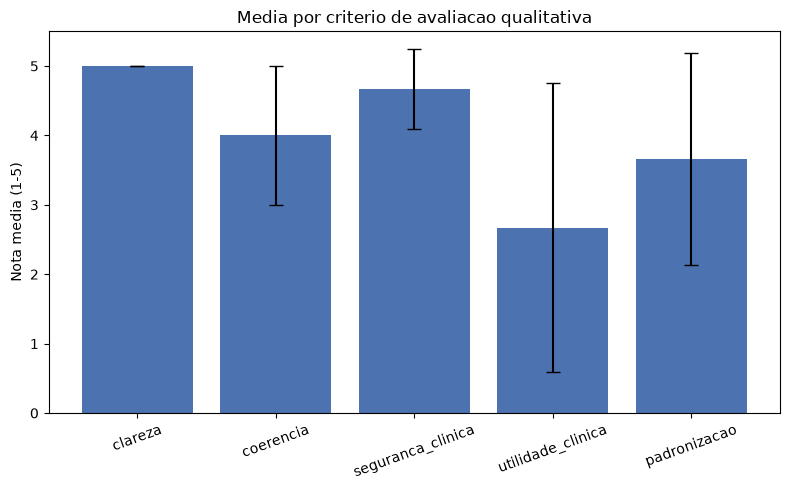

In [19]:
has_manual_scores = stats_summary["n_avaliado"].sum() > 0

if not has_manual_scores:
    print("Nenhuma nota manual foi preenchida ainda (secao 6) - preencha `manual_scores` "
          "e reexecute o notebook a partir da secao 6 para ver os graficos abaixo.")
else:
    # Grafico de barras: media por criterio de avaliacao qualitativa, com desvio padrao.
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.bar(stats_summary.index, stats_summary["media"], yerr=stats_summary["desvio_padrao"],
           capsize=5, color="#4C72B0")
    ax.set_ylim(0, 5.5)
    ax.set_ylabel("Nota media (1-5)")
    ax.set_title("Media por criterio de avaliacao qualitativa")
    ax.tick_params(axis="x", rotation=20)
    plt.tight_layout()
    plt.show()

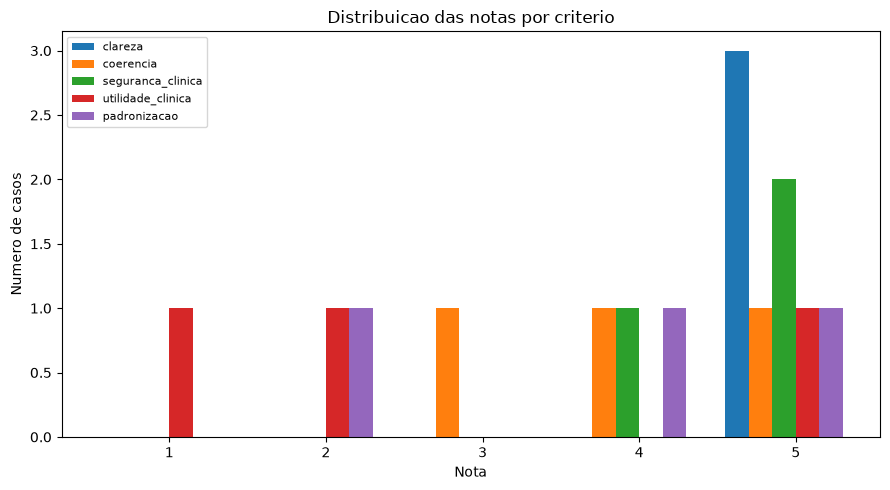

In [20]:
if not has_manual_scores:
    print("Sem notas manuais ainda - nada para plotar.")
else:
    # Distribuicao das notas por criterio, em barras agrupadas.
    fig, ax = plt.subplots(figsize=(9, 5))
    x = np.arange(1, 6)
    width = 0.15
    for i, criterion in enumerate(QUALITATIVE_CRITERIA):
        offset = (i - len(QUALITATIVE_CRITERIA) / 2) * width
        ax.bar(x + offset, score_distribution[criterion], width=width, label=criterion)
    ax.set_xticks(x)
    ax.set_xlabel("Nota")
    ax.set_ylabel("Numero de casos")
    ax.set_title("Distribuicao das notas por criterio")
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

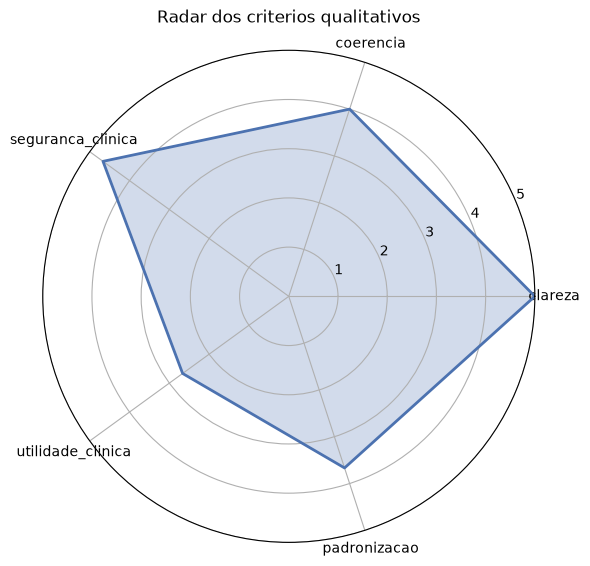

In [21]:
if not has_manual_scores:
    print("Sem notas manuais ainda - nada para plotar.")
else:
    # Radar chart dos criterios qualitativos (matplotlib puro, projecao polar).
    labels = list(QUALITATIVE_CRITERIA)
    values = stats_summary.loc[labels, "media"].tolist()
    angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()

    values += values[:1]
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(6, 6), subplot_kw={"projection": "polar"})
    ax.plot(angles, values, color="#4C72B0", linewidth=2)
    ax.fill(angles, values, color="#4C72B0", alpha=0.25)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels)
    ax.set_ylim(0, 5)
    ax.set_title("Radar dos criterios qualitativos", pad=20)
    plt.tight_layout()
    plt.show()

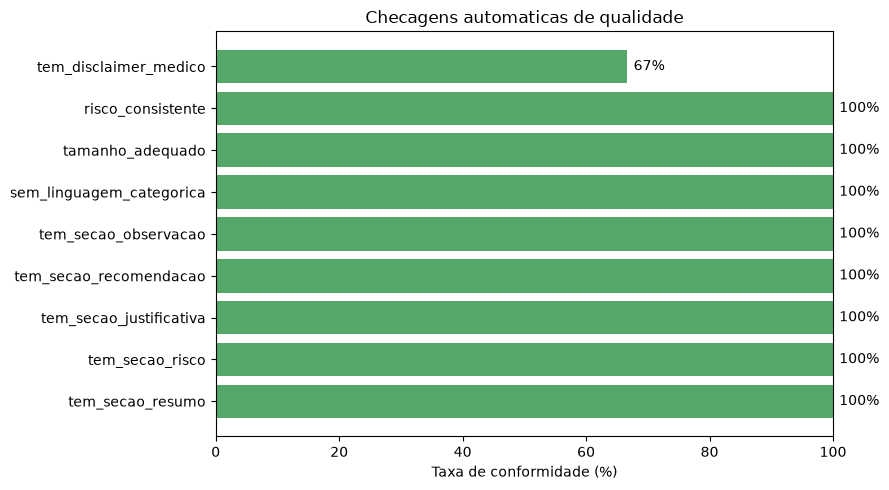

In [22]:
# Grafico de barras: taxa de conformidade automatica por criterio (independe de nota manual).
if automatic_pass_rate.empty:
    print("Sem checagens automaticas para plotar.")
else:
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.barh(automatic_pass_rate.index, automatic_pass_rate.values, color="#55A868")
    ax.set_xlim(0, 100)
    ax.set_xlabel("Taxa de conformidade (%)")
    ax.set_title("Checagens automaticas de qualidade")
    for i, value in enumerate(automatic_pass_rate.values):
        ax.text(value + 1, i, f"{value:.0f}%", va="center")
    plt.tight_layout()
    plt.show()

**Conclusão do tópico:** os gráficos deixam visual o que os números das seções 5 e 7 já indicavam — dá para ver rapidamente em qual critério a LLM está mais forte e onde vale a pena ajustar o prompt.

## 9. Conclusão

Um resumo escrito automaticamente a partir das métricas calculadas nas seções anteriores — não é um texto fixo, muda conforme os dados da amostra.

In [23]:
# Resumo gerado automaticamente a partir das metricas calculadas acima (nao e texto fixo).
n_total = len(sample_df)
n_evaluated = len(evaluated_df)

summary_lines = [
    f"Amostra avaliada: {n_evaluated} de {n_total} casos gerados "
    f"({n_total - n_evaluated} cairam em fallback de erro da API e foram excluidos).",
]

if not automatic_pass_rate.empty:
    overall_automatic_rate = automatic_pass_rate.mean()
    lowest_auto = automatic_pass_rate.idxmin()
    summary_lines.append(
        f"Taxa media de conformidade automatica (formato, disclaimers, consistencia): "
        f"{overall_automatic_rate:.1f}%."
    )
    summary_lines.append(
        f"Criterio automatico com menor conformidade: '{lowest_auto}' "
        f"({automatic_pass_rate[lowest_auto]:.0f}%)."
    )
else:
    summary_lines.append("Nenhum caso pode ser avaliado automaticamente (todos cairam em fallback da API).")

if has_manual_scores:
    overall_manual_mean = stats_summary["media"].mean()
    best_criterion = stats_summary["media"].idxmax()
    worst_criterion = stats_summary["media"].idxmin()
    summary_lines.append(
        f"Nota media geral da avaliacao qualitativa: {overall_manual_mean:.2f} de 5."
    )
    summary_lines.append(
        f"Melhor criterio qualitativo: '{best_criterion}' ({stats_summary.loc[best_criterion, 'media']:.2f}); "
        f"pior criterio: '{worst_criterion}' ({stats_summary.loc[worst_criterion, 'media']:.2f})."
    )
else:
    summary_lines.append(
        "Avaliacao qualitativa manual ainda nao preenchida - preencha a secao 6 para "
        "completar a conclusao com as notas do time."
    )

print("\n".join(f"- {line}" for line in summary_lines))

- Amostra avaliada: 3 de 8 casos gerados (5 cairam em fallback de erro da API e foram excluidos).
- Taxa media de conformidade automatica (formato, disclaimers, consistencia): 96.3%.
- Criterio automatico com menor conformidade: 'tem_disclaimer_medico' (67%).
- Nota media geral da avaliacao qualitativa: 4.00 de 5.
- Melhor criterio qualitativo: 'clareza' (5.00); pior criterio: 'utilidade_clinica' (2.67).
